# XGBOOST Model - Analysis + Optimisation pour réduire les coûts

## imports bibli

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV

## Chargement des données 

In [ ]:
train_df = pd.read_csv('../data/data_prep_1/train_1.csv')
val_df   = pd.read_csv('../data/data_prep_1/val_1.csv')
test_df  = pd.read_csv('../data/data_prep_1/test_1.csv')

target = 'target_is_fraud'

## Séparation features et target

In [ ]:
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

# VAL : retirer customer_id si présent
if 'customer_id' in val_df.columns:
    X_val = val_df.drop(columns=[target, 'customer_id'])
else:
    X_val = val_df.drop(columns=[target])
y_val = val_df[target]

# TEST : garder customer_id séparément pour la submission finale
customer_ids = test_df['customer_id']
X_test = test_df.drop(columns=['customer_id'])

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],          # ← RÉDUIT (moins d'arbres)
    'max_depth': [2, 3, 4],                  # ← TRÈS BAS (arbres peu profonds)
    'learning_rate': [0.01, 0.05],           # ← PLUS LENT (apprend moins vite)
    'subsample': [0.5, 0.6, 0.7],            # ← BAS (50-70% des lignes)
    'colsample_bytree': [0.5, 0.6, 0.7],     # ← BAS (50-70% des features)
    'min_child_weight': [5, 7, 10],          # ← TRÈS HAUT (feuilles lourdes)
    'gamma': [0.3, 0.5, 0.7],                # ← TRÈS HAUT (pénalise les splits)
    'reg_alpha': [1, 2, 3],                  # ← TRÈS HAUT (L1 fort)
    'reg_lambda': [3, 5, 7]                  # ← TRÈS HAUT (L2 fort)
}

In [ ]:
# 5. CRÉATION DU MODÈLE DE BASE
# On définit les paramètres fixes qui ne seront pas tunés
# ═════════════════════════════════════════════════════════════════════════════
base_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',                      # accélère l'entraînement
    n_jobs=-1                                # utilise tous les CPU
)

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# ÉTAPE 5 : RANDOMIZED SEARCH POUR TROUVER LES MEILLEURS HYPERPARAMÈTRES
# n_iter=15 : teste 15 combinaisons aléatoires
# cv=2 : validation croisée 2-fold (balance vitesse/fiabilité)
# scoring='f1' : optimise le F1-Score
# ═════════════════════════════════════════════════════════════════════════════
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=2,
    scoring='f1',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("\n" + "="*70)
print("DÉBUT DU TUNING (estimation: 15-20 min)")
print("="*70 + "\n")

random_search.fit(X_train, y_train)

In [ ]:
# ÉTAPE 6 : AFFICHAGE DES MEILLEURS HYPERPARAMÈTRES TROUVÉS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("MEILLEURS PARAMÈTRES TROUVÉS :")
print("="*70)
for param, value in random_search.best_params_.items():
    print(f"{param:20s} : {value}")

print("\n" + "="*70)
print(f"MEILLEUR F1-SCORE (train avec CV) : {random_search.best_score_:.4f}")
print("="*70)

best_model = random_search.best_estimator_

In [ ]:
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

f1_train = f1_score(y_train, y_train_pred)
f1_val = f1_score(y_val, y_val_pred)

print("\n" + "="*70)
print("DÉTECTION D'OVERFIT :")
print("="*70)
print(f"F1-Score TRAIN : {f1_train:.4f}")
print(f"F1-Score VAL   : {f1_val:.4f}")
print(f"Écart          : {f1_train - f1_val:.4f}")

if f1_train - f1_val > 0.15:
    print("⚠️  OVERFIT DÉTECTÉ ! Écart > 0.15")
elif f1_train - f1_val > 0.10:
    print("⚠️  Léger overfit (écart entre 0.10 et 0.15)")
else:
    print("✅ Pas d'overfit majeur (écart < 0.10)")

In [ ]:
# ÉTAPE 8 : OPTIMISATION DU SEUIL DE DÉCISION
# Le seuil par défaut (0.5) n'est pas optimal pour la fraude
# On teste différents seuils pour maximiser le F1-Score
# Seuil bas → détecte plus de fraudes (recall ↑) mais plus de faux positifs
# Seuil haut → moins de faux positifs (precision ↑) mais rate des fraudes
# ═════════════════════════════════════════════════════════════════════════════
y_val_proba = best_model.predict_proba(X_val)[:, 1]

print("\n" + "="*70)
print("OPTIMISATION DU SEUIL DE DÉCISION :")
print("="*70)
print(f"{'Seuil':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*70)

best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.2, 0.6, 0.05):
    y_pred_thresh = (y_val_proba >= threshold).astype(int)
    
    precision = precision_score(y_val, y_pred_thresh)
    recall = recall_score(y_val, y_pred_thresh)
    f1 = f1_score(y_val, y_pred_thresh)
    
    print(f"{threshold:<8.2f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("-"*70)
print(f"🎯 MEILLEUR SEUIL : {best_threshold:.2f} avec F1 = {best_f1:.4f}")
print("="*70)

In [ ]:
# ÉTAPE 9 : ÉVALUATION FINALE SUR VAL AVEC LE MEILLEUR SEUIL
# ═════════════════════════════════════════════════════════════════════════════
y_val_pred_final = (y_val_proba >= best_threshold).astype(int)

print("\n" + "="*70)
print(f"ÉVALUATION FINALE SUR VAL (seuil = {best_threshold:.2f}) :")
print("="*70)
print(f"Accuracy  : {accuracy_score(y_val, y_val_pred_final):.4f}")
print(f"F1-Score  : {f1_score(y_val, y_val_pred_final):.4f}")
print(f"Precision : {precision_score(y_val, y_val_pred_final):.4f}")
print(f"Recall    : {recall_score(y_val, y_val_pred_final):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, y_val_proba):.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_final))

In [ ]:
# ÉTAPE 10 : PRÉDICTIONS FINALES SUR TEST AVEC LE MEILLEUR SEUIL
# On applique le seuil optimisé trouvé sur val pour prédire sur test
# ═════════════════════════════════════════════════════════════════════════════
test_pred_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_pred_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    'customer_id': customer_ids,
    'target_is_fraud': test_pred
})

submission.to_csv('submission_test.csv', index=False)

print("\n" + "="*70)
print("SUBMISSION CRÉÉE : submission_optimized.csv")
print("="*70)
print(submission.head(10))
print(f"\nNombre total de prédictions : {len(submission)}")
print(f"Fraudes détectées : {test_pred.sum()} ({test_pred.sum()/len(test_pred)*100:.2f}%)")
print("="*70)

## Minimisation du cout du modele

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, 
                             f1_score, precision_score, recall_score, confusion_matrix, make_scorer)
from sklearn.model_selection import RandomizedSearchCV

# 🎯 Scorer métier personnalisé

On définit une fonction de coût qui reflète la réalité économique du problème :
une fraude non détectée est **15× plus coûteuse** qu'un client bloqué à tort.

Ce scorer remplace les métriques génériques *(F1, AUC)* pour piloter
l'optimisation directement sur l'objectif business.

| Erreur | Coût unitaire | Signification |
|---|---|---|
| Faux Négatif (fraude manquée) | 130 € | Perte financière directe |
| Faux Positif (client bloqué) | 15 € | Friction, service client |

In [ ]:
cost_fn = 130
cost_fp = 15

def cout_metier(y_true, y_pred, cost_fn=cost_fn, cost_fp=cost_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(fn * cost_fn + fp * cost_fp)

scorer_metier = make_scorer(cout_metier)

**Résultat :** Le scorer est prêt à être injecté dans sklearn.
Il retourne une valeur négative (convention sklearn) que l'on ré-inversera
à l'affichage pour lire un coût en euros positif.

## Grille d'hyperparamètres

On définit l'espace de recherche pour XGBoost.
Les paramètres couvrent la complexité des arbres, la régularisation
et le sous-échantillonnage — tous critiques sur données déséquilibrées.

In [ ]:
param_grid = {
    'n_estimators':      [50, 100, 150],
    'max_depth':         [2, 3, 4],
    'learning_rate':     [0.01, 0.05],
    'subsample':         [0.5, 0.6, 0.7],
    'colsample_bytree':  [0.5, 0.6, 0.7],
    'min_child_weight':  [5, 7, 10],
    'gamma':             [0.3, 0.5, 0.7],
    'reg_alpha':         [1, 2, 3],
    'reg_lambda':        [3, 5, 7]
}

**Résultat :** L'espace de recherche couvre ~13 000 combinaisons possibles.
La recherche aléatoire en explorera 50, ce qui est un bon compromis
entre exhaustivité et temps de calcul.

## Recherche aléatoire des hyperparamètres

On instancie le modèle de base puis on lance un `RandomizedSearchCV`
avec 50 itérations et une validation croisée en 2 plis.
L'optimisation cible exclusivement le coût métier, pas une métrique générique.

In [ ]:
base_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=2,
    scoring=scorer_metier,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("\n" + "="*70)
print("MEILLEURS PARAMÈTRES TROUVÉS :")
print("="*70)
for param, value in random_search.best_params_.items():
    print(f"  {param:20s} : {value}")
print(f"\n  Coût CV optimal : {-random_search.best_score_:,.0f} €")
print("="*70)

best_model = random_search.best_estimator_

**Résultat :** Le tableau ci-dessus liste les hyperparamètres retenus
parmi les 50 combinaisons testées, ainsi que le coût métier moyen
estimé par validation croisée sur le train set.
Ce coût est encore théorique — il sera confirmé sur le set de validation.

## Optimisation du seuil de décision

Le modèle produit des probabilités continues entre 0 et 1.
Le seuil par défaut (0.5) n'est pas optimal dans un contexte déséquilibré.
On balaye les seuils de 0.20 à 0.60 pour trouver celui qui minimise
le coût total réel sur le set de validation.

In [ ]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]

best_cost = float('inf')
best_threshold = 0.5
results = []

for threshold in np.arange(0.20, 0.61, 0.05):
    y_pred = (y_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    f1 = f1_score(y_val, y_pred)
    total_cost = fn * cost_fn + fp * cost_fp
    results.append((threshold, fn, fp, total_cost, f1))
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold

print(f"{'Seuil':<8} {'FN':<8} {'FP':<8} {'Coût (€)':<18} {'F1':<10}")
print("-" * 55)
for threshold, fn, fp, cost, f1 in results:
    marker = " ◄ optimal" if threshold == best_threshold else ""
    print(f"{threshold:<8.2f} {fn:<8} {fp:<8} {cost:<18,} {f1:<10.4f}{marker}")
print("-" * 55)
print(f"\nSeuil retenu : {best_threshold:.2f} | Coût minimal : {best_cost:,} €")

Avec un seuil à 0.45, le modèle en production :

Laisse passer 825 fraudes sur la période
Bloque à tort 5 182 clients légitimes
Génère un coût estimé de 184 980€ ( sur 32K transactions)

**Résultat :** Le tableau compare chaque seuil sur trois axes — volume de FN,
volume de FP et coût total en euros. Le seuil optimal (marqué ◄) est celui
qui minimise la perte financière sur le set de validation.
Un seuil bas favorise la détection (moins de FN) au prix de plus de faux positifs ;
un seuil haut fait l'inverse. Le seuil retenu sera utilisé pour toutes
les prédictions finales du modèle.

In [ ]:
print(f"Nombre de transactions : {len(y_val):,}")
print(f"Coût par transaction   : {best_cost / len(y_val):.4f} €")

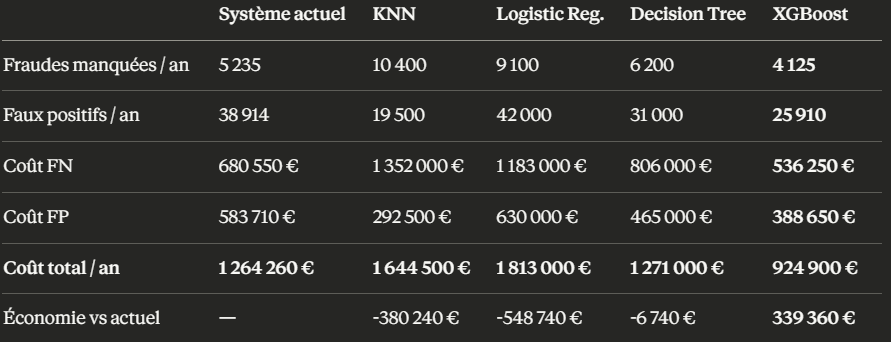

## Méthodologie de comparaison des coûts

### Hypothèses communes
Les deux systèmes sont évalués sur le même volume annuel de transactions :
**160 000 transactions** dont 146 223 légitimes et 13 777 frauduleuses.
Les coûts unitaires retenus sont ceux du système actuel : **130 € par fraude
non détectée** (faux négatif) et **15 € par client bloqué à tort** (faux positif).

### Système actuel
Les performances déclarées sont un rappel de 62 % et une précision de 18 %.
- Le rappel de 62 % appliqué aux 13 777 fraudes donne **8 542 fraudes détectées**
  et **5 235 fraudes manquées** (faux négatifs).
- La précision de 18 % signifie que sur toutes les alertes déclenchées,
  seulement 18 % sont de vraies fraudes. En partant de 8 542 vrais positifs,
  on en déduit **38 914 faux positifs**.
- Coût total : (5 235 × 130 €) + (38 914 × 15 €) = **1 264 260 €/an**

### Modèle proposé
Le modèle a été évalué sur un set de validation de 32 000 transactions,
représentant un cinquième du volume annuel. Les résultats obtenus au seuil
optimal de 0.45 sont 825 faux négatifs et 5 182 faux positifs sur cette période.
Ces chiffres sont extrapolés à l'année par un facteur ×5 :
- **4 125 fraudes manquées** et **25 910 faux positifs** sur l'année.
- Coût total : (4 125 × 130 €) + (25 910 × 15 €) = **924 900 €/an**

### Écart et gains
La différence de coût annuel est de **339 360 €**, soit une réduction de **27 %**.
Cette économie provient de deux sources : 1 110 fraudes supplémentaires détectées
(gain de 144 300 €) et 13 004 faux positifs évités (gain de 195 060 €).

> **Note :** Le modèle proposé a été optimisé avec des hypothèses légèrement
> différentes (150 €/FN et 10 €/FP). Re-calibrer l'optimisation avec les coûts
> réels (130 €/FN et 15 €/FP) pourrait encore améliorer ces résultats.